In [2]:
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Load Data
X_train = pd.read_csv("X_train_clean.csv")
X_test = pd.read_csv("X_test_clean.csv")

y_train = pd.read_csv("y_train.csv").values.ravel()
y_test = pd.read_csv("y_test.csv").values.ravel()

# Baseline SVM
svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        kernel='rbf',
        class_weight='balanced',
        random_state=42
    ))
])

# Train
svm.fit(X_train, y_train)

# Predictions
train_pred = svm.predict(X_train)
test_pred = svm.predict(X_test)

# In-Sample Performance
print("="*50)
print("IN-SAMPLE PERFORMANCE")
print("="*50)

print("Accuracy :", accuracy_score(y_train, train_pred))
print("Precision:", precision_score(y_train, train_pred, average='weighted'))
print("Recall   :", recall_score(y_train, train_pred, average='weighted'))
print("F1 Score :", f1_score(y_train, train_pred, average='weighted'))

# Out-of-Sample Performance
print("\n" + "="*50)
print("OUT-OF-SAMPLE PERFORMANCE")
print("="*50)

print("Accuracy :", accuracy_score(y_test, test_pred))
print("Precision:", precision_score(y_test, test_pred, average='weighted'))
print("Recall   :", recall_score(y_test, test_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, test_pred, average='weighted'))

print("\nClassification Report")
print(classification_report(y_test, test_pred))

IN-SAMPLE PERFORMANCE
Accuracy : 0.9697500654542525
Precision: 0.9736474756710938
Recall   : 0.9697500654542525
F1 Score : 0.970985703806574

OUT-OF-SAMPLE PERFORMANCE
Accuracy : 0.5165372254954472
Precision: 0.5835772338796995
Recall   : 0.5165372254954472
F1 Score : 0.5371764550390303

Classification Report
              precision    recall  f1-score   support

           0       0.22      0.33      0.26      1525
           1       0.00      0.01      0.00      1667
           2       0.35      0.32      0.33      1040
           3       0.01      0.01      0.01      1012
           4       0.65      0.28      0.40      4827
           5       0.20      0.29      0.24      1388
           6       0.32      0.29      0.31      1231
           7       0.75      0.72      0.74     17182

    accuracy                           0.52     29872
   macro avg       0.31      0.28      0.28     29872
weighted avg       0.58      0.52      0.54     29872



In [3]:
from sklearn.model_selection import train_test_split, GridSearchCV

# 80-20 Split
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=42
)

# Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        class_weight='balanced',
        random_state=42
    ))
])

# Hyperparameter Grid
param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['rbf'],
    'svm__gamma': ['scale', 0.01, 0.001]
}

# Grid Search
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_sub, y_train_sub)

print("Best Parameters:")
print(grid_search.best_params_)

print("Best CV Score:")
print(grid_search.best_score_)

best_svm = grid_search.best_estimator_

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best Parameters:
{'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV Score:
0.9789070236678789


In [4]:
# In-Sample
train_pred = best_svm.predict(X_train_sub)

print("="*50)
print("IN-SAMPLE PERFORMANCE")
print("="*50)

print("Accuracy :", accuracy_score(y_train_sub, train_pred))
print("Precision:", precision_score(y_train_sub, train_pred, average='weighted'))
print("Recall   :", recall_score(y_train_sub, train_pred, average='weighted'))
print("F1 Score :", f1_score(y_train_sub, train_pred, average='weighted'))

# Validation
val_pred = best_svm.predict(X_val)

print("\n" + "="*50)
print("VALIDATION PERFORMANCE")
print("="*50)

print("Accuracy :", accuracy_score(y_val, val_pred))
print("Precision:", precision_score(y_val, val_pred, average='weighted'))
print("Recall   :", recall_score(y_val, val_pred, average='weighted'))
print("F1 Score :", f1_score(y_val, val_pred, average='weighted'))

# Test
test_pred = best_svm.predict(X_test)

print("\n" + "="*50)
print("OUT-OF-SAMPLE PERFORMANCE")
print("="*50)

print("Accuracy :", accuracy_score(y_test, test_pred))
print("Precision:", precision_score(y_test, test_pred, average='weighted'))
print("Recall   :", recall_score(y_test, test_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, test_pred, average='weighted'))

print("\nClassification Report")
print(classification_report(y_test, test_pred))

IN-SAMPLE PERFORMANCE
Accuracy : 0.9828979499358044
Precision: 0.9845494200449131
Recall   : 0.9828979499358044
F1 Score : 0.98339076291967

VALIDATION PERFORMANCE
Accuracy : 0.9815722341568206
Precision: 0.9833234001574546
Recall   : 0.9815722341568206
F1 Score : 0.9821219148464778

OUT-OF-SAMPLE PERFORMANCE
Accuracy : 0.5296598821638993
Precision: 0.6019841680464052
Recall   : 0.5296598821638993
F1 Score : 0.5434799780488632

Classification Report
              precision    recall  f1-score   support

           0       0.31      0.37      0.33      1525
           1       0.00      0.00      0.00      1667
           2       0.25      0.30      0.27      1040
           3       0.07      0.08      0.07      1012
           4       0.78      0.25      0.38      4827
           5       0.25      0.34      0.29      1388
           6       0.32      0.27      0.30      1231
           7       0.74      0.75      0.74     17182

    accuracy                           0.53     29872
   m

In [5]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Baseline SVM", "Tuned SVM"],
    "Accuracy": [
        accuracy_score(y_test, svm.predict(X_test)),
        accuracy_score(y_test, best_svm.predict(X_test))
    ],
    "Precision": [
        precision_score(y_test, svm.predict(X_test), average='weighted'),
        precision_score(y_test, best_svm.predict(X_test), average='weighted')
    ],
    "Recall": [
        recall_score(y_test, svm.predict(X_test), average='weighted'),
        recall_score(y_test, best_svm.predict(X_test), average='weighted')
    ],
    "F1 Score": [
        f1_score(y_test, svm.predict(X_test), average='weighted'),
        f1_score(y_test, best_svm.predict(X_test), average='weighted')
    ]
})

print(comparison.round(4))

          Model  Accuracy  Precision  Recall  F1 Score
0  Baseline SVM    0.5165     0.5836  0.5165    0.5372
1     Tuned SVM    0.5297     0.6020  0.5297    0.5435


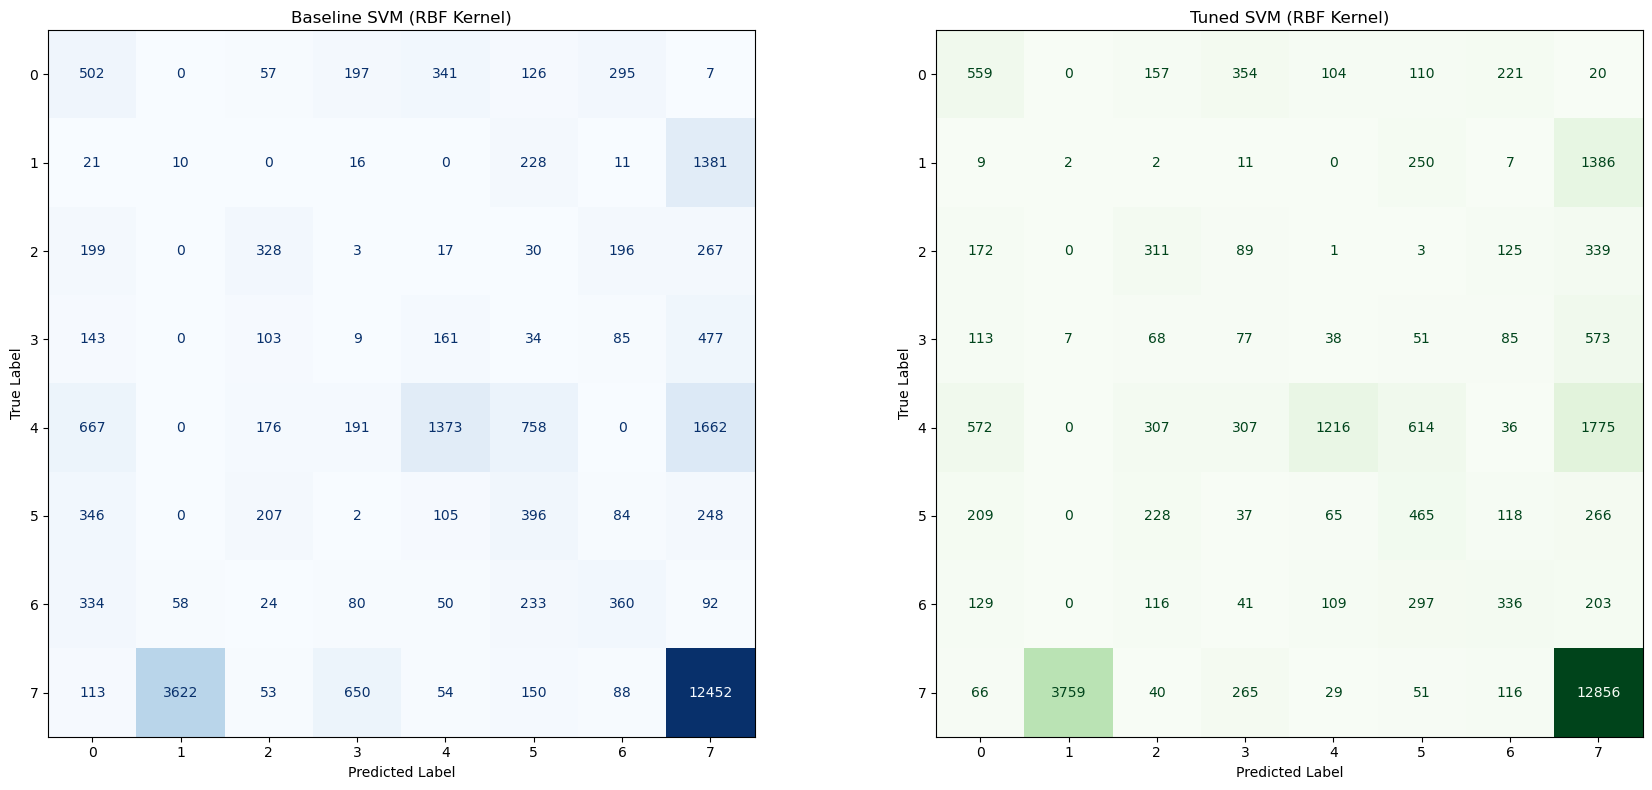

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predictions
baseline_pred = svm.predict(X_test)
tuned_pred = best_svm.predict(X_test)

# Confusion Matrices
cm_baseline = confusion_matrix(y_test, baseline_pred)
cm_tuned = confusion_matrix(y_test, tuned_pred)

# Plot Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# ---------------- Baseline SVM ----------------
ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline,
    display_labels=svm.classes_
).plot(
    ax=axes[0],
    cmap="Blues",
    colorbar=False,
    values_format='d'
)

axes[0].set_title("Baseline SVM (RBF Kernel)")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# ---------------- Tuned SVM ----------------
ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=best_svm.classes_
).plot(
    ax=axes[1],
    cmap="Greens",
    colorbar=False,
    values_format='d'
)

axes[1].set_title("Tuned SVM (RBF Kernel)")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

# Predictions
baseline_pred = svm.predict(X_test)
tuned_pred = best_svm.predict(X_test)

# Classification Reports
baseline_report = pd.DataFrame(
    classification_report(
        y_test,
        baseline_pred,
        output_dict=True,
        zero_division=0
    )
).transpose()

tuned_report = pd.DataFrame(
    classification_report(
        y_test,
        tuned_pred,
        output_dict=True,
        zero_division=0
    )
).transpose()

precision_table = pd.DataFrame({
    "Class": baseline_report.index[:-3],
    "Baseline Precision": baseline_report.loc[
        baseline_report.index[:-3], "precision"
    ].values,
    "Tuned Precision": tuned_report.loc[
        tuned_report.index[:-3], "precision"
    ].values
})

precision_table = precision_table.round(4)

print("Precision Comparison")
display(precision_table)

recall_table = pd.DataFrame({
    "Class": baseline_report.index[:-3],
    "Baseline Recall": baseline_report.loc[
        baseline_report.index[:-3], "recall"
    ].values,
    "Tuned Recall": tuned_report.loc[
        tuned_report.index[:-3], "recall"
    ].values
})

recall_table = recall_table.round(4)

print("Recall Comparison")
display(recall_table)

f1_table = pd.DataFrame({
    "Class": baseline_report.index[:-3],
    "Baseline F1-Score": baseline_report.loc[
        baseline_report.index[:-3], "f1-score"
    ].values,
    "Tuned F1-Score": tuned_report.loc[
        tuned_report.index[:-3], "f1-score"
    ].values
})

f1_table = f1_table.round(4)

print("F1-Score Comparison")
display(f1_table)

import numpy as np
from sklearn.metrics import accuracy_score

classes = np.unique(y_test)

accuracy_list = []

for cls in classes:

    y_true_binary = (y_test == cls).astype(int)

    baseline_binary = (baseline_pred == cls).astype(int)
    tuned_binary = (tuned_pred == cls).astype(int)

    accuracy_list.append([
        cls,
        accuracy_score(y_true_binary, baseline_binary),
        accuracy_score(y_true_binary, tuned_binary)
    ])

accuracy_table = pd.DataFrame(
    accuracy_list,
    columns=[
        "Class",
        "Baseline Accuracy",
        "Tuned Accuracy"
    ]
)

accuracy_table = accuracy_table.round(4)

print("Individual Class Accuracy")
display(accuracy_table)

comparison_table = pd.DataFrame({
    "Class": baseline_report.index[:-3],

    "Baseline Precision":
        baseline_report.loc[
            baseline_report.index[:-3],
            "precision"
        ].values,

    "Tuned Precision":
        tuned_report.loc[
            tuned_report.index[:-3],
            "precision"
        ].values,

    "Baseline Recall":
        baseline_report.loc[
            baseline_report.index[:-3],
            "recall"
        ].values,

    "Tuned Recall":
        tuned_report.loc[
            tuned_report.index[:-3],
            "recall"
        ].values,

    "Baseline F1":
        baseline_report.loc[
            baseline_report.index[:-3],
            "f1-score"
        ].values,

    "Tuned F1":
        tuned_report.loc[
            tuned_report.index[:-3],
            "f1-score"
        ].values,

    "Baseline Accuracy":
        accuracy_table["Baseline Accuracy"],

    "Tuned Accuracy":
        accuracy_table["Tuned Accuracy"]
})

comparison_table = comparison_table.round(4)

print("SVM (RBF Kernel): Baseline vs Tuned")
display(comparison_table)